# Analise de Erros Brutos

Um "erro bruto" e quando um modelo previu uma classe com confianca alta (>= 70%) e o resultado real foi a classe contraria. Ou seja, o modelo nao ficou em cima do muro, ele errou convicto.

Esse notebook usa a tabela de votos por jogo (janela 15, gerada por `scripts/gerar_tabela_votos.py`) para:
- Rankear as temporadas por taxa de erro bruto (pior para melhor)
- Rankear os modelos por quantidade total de erros brutos
- Plotar os dois rankings em grafico de barras

## Importar bibliotecas

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Configuracao

- `ARQUIVO_VOTOS`: tabela de votos por jogo, uma aba por temporada
- `LIMITE_CONFIANCA`: confianca minima (%) para considerar que o modelo errou feio
- `MODELOS`: nomes dos 5 modelos, na mesma ordem usada nas colunas da tabela

In [2]:
PASTA = os.path.abspath(os.path.join('..', 'results', 'tabela_votos_por_jogo', 'janela_15'))
ARQUIVO_VOTOS = os.path.join(PASTA, 'tabela_votos_janela_15.xlsx')

LIMITE_CONFIANCA = 70
MODELOS = ['SVM', 'KNN', 'ExtraTrees', 'LightGBM', 'Regressao']

## Carregar todas as temporadas e calcular o erro bruto por jogo/modelo

Li todas as abas do arquivo de votos, empilhei em um unico DataFrame com a coluna `Temporada`, e marquei `True`/`False` por modelo quando ele errou feio naquele jogo.

In [3]:
xls = pd.ExcelFile(ARQUIVO_VOTOS)

partes = []
for temporada in xls.sheet_names:
    df = xls.parse(temporada)
    df['Temporada'] = temporada
    partes.append(df)

dados = pd.concat(partes, ignore_index=True)

for m in MODELOS:
    dados[f'{m}_erro_bruto'] = (dados[f'{m}_pred'] != dados['Target']) & (dados[f'{m}_prob(%)'] >= LIMITE_CONFIANCA)

dados['Qtd_Erros_Brutos'] = dados[[f'{m}_erro_bruto' for m in MODELOS]].sum(axis=1)

print(f'Total de jogos (todas as temporadas): {len(dados)}')
print(f'Jogos com pelo menos 1 erro bruto: {(dados["Qtd_Erros_Brutos"] >= 1).sum()}')

Total de jogos (todas as temporadas): 3510
Jogos com pelo menos 1 erro bruto: 965


## Ranking de temporadas por taxa de erro bruto

Usei a taxa (% de jogos da temporada com pelo menos 1 erro bruto) em vez do numero absoluto, porque as temporadas nao tem a mesma quantidade de jogos. Ordenei da pior para a melhor.

In [4]:
ranking_temporadas = dados.groupby('Temporada').agg(
    Jogos=('Target', 'size'),
    Jogos_Com_Erro_Bruto=('Qtd_Erros_Brutos', lambda s: (s >= 1).sum()),
)
ranking_temporadas['Taxa_Erro_Bruto(%)'] = (
    ranking_temporadas['Jogos_Com_Erro_Bruto'] / ranking_temporadas['Jogos'] * 100
).round(1)

ranking_temporadas = ranking_temporadas.sort_values('Taxa_Erro_Bruto(%)', ascending=False)

print('=== RANKING DE TEMPORADAS (pior para melhor) ===')
print(ranking_temporadas.to_string())

=== RANKING DE TEMPORADAS (pior para melhor) ===
           Jogos  Jogos_Com_Erro_Bruto  Taxa_Erro_Bruto(%)
Temporada                                                 
2009-2010    146                    49                33.6
2018-2019    202                    64                31.7
2016-2017    244                    75                30.7
2013-2014    300                    87                29.0
2015-2016    239                    69                28.9
2022-2023    296                    84                28.4
2020-2021    250                    68                27.2
2014-2015    269                    73                27.1
2023-2024    370                   100                27.0
2012-2013    334                    87                26.0
2019-2020    191                    49                25.7
2021-2022    288                    74                25.7
2011-2012    160                    40                25.0
2008-2009    221                    46                20.8


## Ranking de modelos por total de erros brutos

Somei quantas vezes cada modelo errou feio, em todas as temporadas juntas. Ordenei do que mais errou feio para o que menos errou.

In [5]:
ranking_modelos = pd.DataFrame({
    'Modelo': MODELOS,
    'Erros_Brutos': [dados[f'{m}_erro_bruto'].sum() for m in MODELOS],
})
ranking_modelos['Taxa_Erro_Bruto(%)'] = (ranking_modelos['Erros_Brutos'] / len(dados) * 100).round(1)
ranking_modelos = ranking_modelos.sort_values('Erros_Brutos', ascending=False).reset_index(drop=True)

print('=== RANKING DE MODELOS (mais erros brutos para menos) ===')
print(ranking_modelos.to_string(index=False))

=== RANKING DE MODELOS (mais erros brutos para menos) ===
    Modelo  Erros_Brutos  Taxa_Erro_Bruto(%)
  LightGBM           651                18.5
       KNN           438                12.5
 Regressao           358                10.2
ExtraTrees           302                 8.6
       SVM           209                 6.0


## Graficos

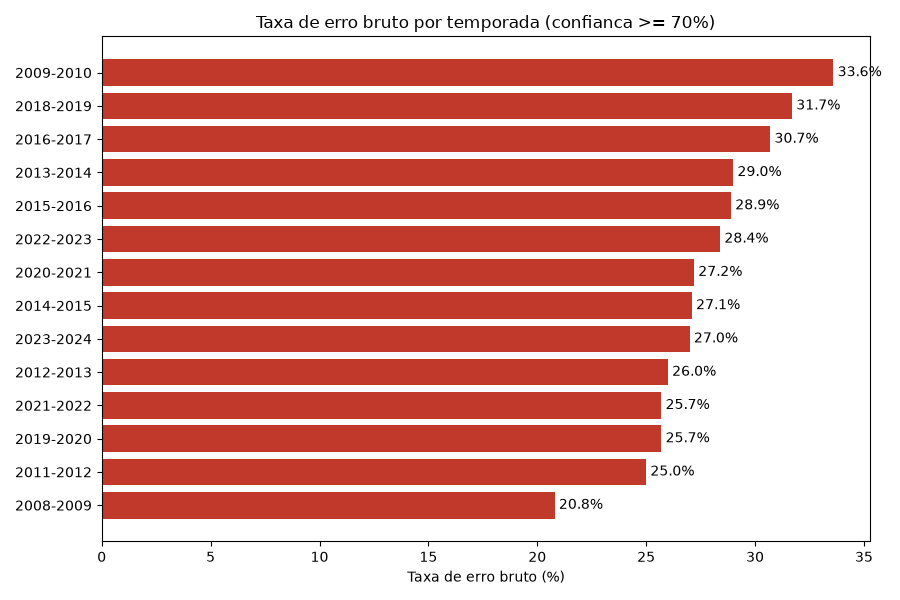

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ordem = ranking_temporadas.sort_values('Taxa_Erro_Bruto(%)')
ax.barh(ordem.index, ordem['Taxa_Erro_Bruto(%)'], color='#c0392b')
ax.set_xlabel('Taxa de erro bruto (%)')
ax.set_title(f'Taxa de erro bruto por temporada (confianca >= {LIMITE_CONFIANCA}%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

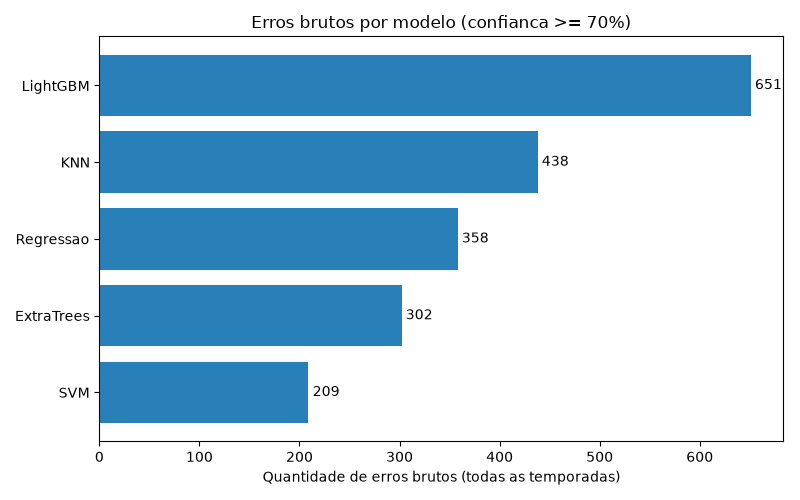

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ordem_modelos = ranking_modelos.sort_values('Erros_Brutos')
ax.barh(ordem_modelos['Modelo'], ordem_modelos['Erros_Brutos'], color='#2980b9')
ax.set_xlabel('Quantidade de erros brutos (todas as temporadas)')
ax.set_title(f'Erros brutos por modelo (confianca >= {LIMITE_CONFIANCA}%)')
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.show()